In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# load cleaned merged dataset
df = pd.read_csv("../data/cleaned/nyts_2021_2023_clean.csv")
print(df.shape)
df.head()

(12588, 26)


,age,sex,grade,sm_usage,sm_freq,platform_fb,platform_insta,platform_sc,platform_tt,platform_twitch,...,creator_real_life,creator_online_friends,creator_influencers,creator_brands_sellers,creator_news,creator_public_health,creator_other,usage,ecig_current,year
0,4.0,1.0,2.0,8.0,2.0,0.0,1.0,1.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,2021
1,4.0,1.0,1.0,7.0,4.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,2021
2,5.0,1.0,2.0,8.0,5.0,0.0,1.0,1.0,1.0,0.0,...,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0,2021
3,6.0,2.0,3.0,7.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,2.0,1,2021
4,7.0,1.0,3.0,2.0,5.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,2021


In [4]:
# create basic overview table
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nYears in dataset:")
print(df["year"].value_counts().sort_index())

print("\nCurrent e-cigarette use rate overall:")
print(df["ecig_current"].value_counts(normalize=True))

Dataset shape: (12588, 26)

Columns:
['age', 'sex', 'grade', 'sm_usage', 'sm_freq', 'platform_fb', 'platform_insta', 'platform_sc', 'platform_tt', 'platform_twitch', 'platform_twitter', 'platform_reddit', 'platform_yt', 'platform_other', 'post_freq', 'interact_freq', 'creator_real_life', 'creator_online_friends', 'creator_influencers', 'creator_brands_sellers', 'creator_news', 'creator_public_health', 'creator_other', 'usage', 'ecig_current', 'year']

Years in dataset:
year
2021    3590
2022    5720
2023    3278
Name: count, dtype: int64

Current e-cigarette use rate overall:
ecig_current
0    0.547029
1    0.452971
Name: proportion, dtype: float64


      vaping_rate     n
year                   
2021     0.400000  3590
2022     0.472203  5720
2023     0.477425  3278


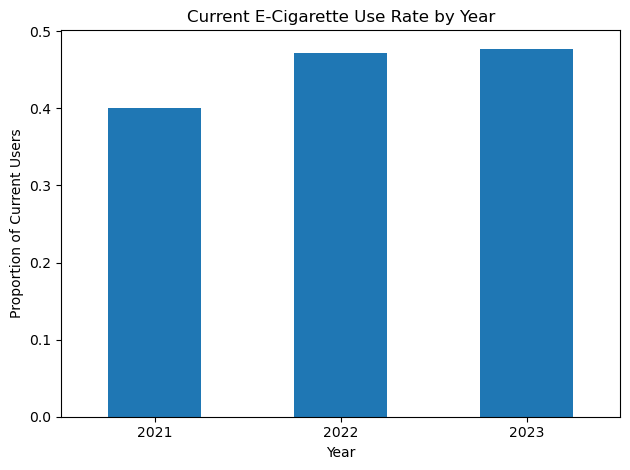

In [5]:
# table of vaping rate per year
vaping_rate_by_year = df.groupby("year")["ecig_current"].agg(["mean", "count"])
vaping_rate_by_year = vaping_rate_by_year.rename(columns={"mean": "vaping_rate", "count": "n"})
print(vaping_rate_by_year)

# plot it
vaping_rate_by_year["vaping_rate"].plot(kind="bar")

plt.title("Current E-Cigarette Use Rate by Year")
plt.xlabel("Year")
plt.ylabel("Proportion of Current Users")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

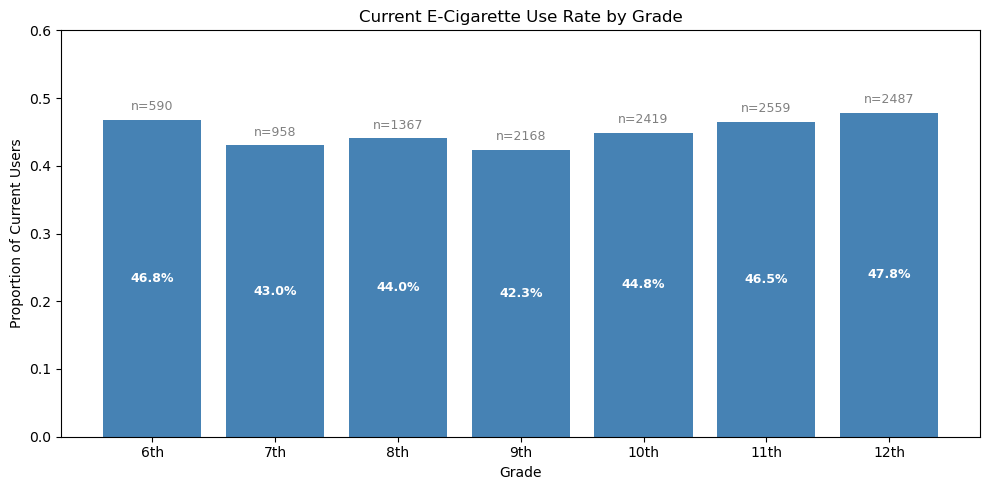

In [23]:
grade_counts = df.groupby("grade")["ecig_current"].agg(["mean", "count"]).reset_index()
grade_counts.columns = ["grade_code", "vaping_rate", "n"]

grade_counts = grade_counts[grade_counts["grade_code"] != 8.0] # remove ungraded to avoid distorting the data

grade_map = {1.0: "6th", 2.0: "7th", 3.0: "8th", 4.0: "9th",
             5.0: "10th", 6.0: "11th", 7.0: "12th"}

grade_counts["grade_label"] = grade_counts["grade_code"].map(grade_map)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(grade_counts["grade_label"], grade_counts["vaping_rate"], color="steelblue")

for bar, n, rate in zip(bars, grade_counts["n"], grade_counts["vaping_rate"]):
    # sample size above bar
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"n={n}", ha="center", va="bottom", fontsize=9, color="gray")
    # percentage inside bar
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() / 2,
            f"{rate:.1%}", ha="center", va="center", fontsize=9, color="white", fontweight="bold")

ax.set_title("Current E-Cigarette Use Rate by Grade")
ax.set_xlabel("Grade")
ax.set_ylabel("Proportion of Current Users")
ax.set_ylim(0, 0.6)
plt.tight_layout()
plt.show()

              sm_usage   sm_freq  post_freq  interact_freq
ecig_current                                              
0             6.779262  3.295091   1.332849       1.776213
1             6.651526  3.554192   1.637145       2.135566


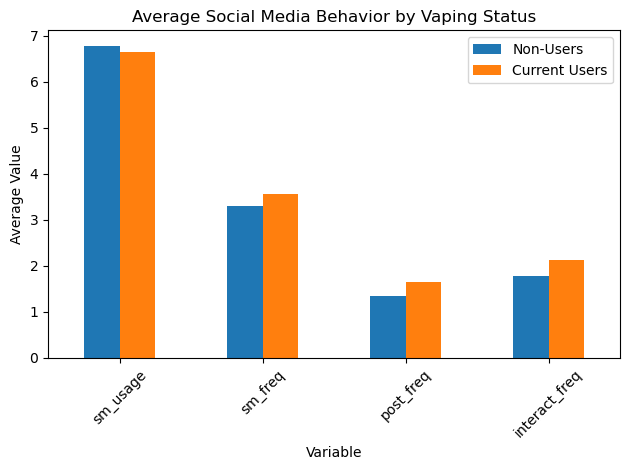

In [24]:
# plot the avg social media behavior by vaping status
exposure_summary = df.groupby("ecig_current")[["sm_usage", "sm_freq", "post_freq", "interact_freq"]].mean()
print(exposure_summary)

exposure_summary.T.plot(kind="bar")

plt.title("Average Social Media Behavior by Vaping Status")
plt.xlabel("Variable")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.legend(["Non-Users", "Current Users"])
plt.tight_layout()
plt.show()

In [19]:
# table on most popular platforms among current e-cig users by year
platform_cols = [
    "platform_fb", "platform_insta", "platform_sc", "platform_tt",
    "platform_twitch", "platform_twitter", "platform_reddit",
    "platform_yt", "platform_other"
]

platform_labels = {
    "platform_fb": "Facebook",
    "platform_insta": "Instagram",
    "platform_sc": "Snapchat",
    "platform_tt": "TikTok",
    "platform_twitch": "Twitch",
    "platform_twitter": "Twitter",
    "platform_reddit": "Reddit",
    "platform_yt": "YouTube",
    "platform_other": "Other"
}

ecig_users = df[df["ecig_current"] == 1]

platform_by_year = ecig_users.groupby("year")[platform_cols].mean()
platform_by_year = platform_by_year.rename(columns=platform_labels)

print(platform_by_year)

      Facebook  Instagram  Snapchat    TikTok   Twitch   Twitter    Reddit  \
year                                                                         
2021  0.143454   0.456825  0.559889  0.506964  0.00000  0.149025  0.075905   
2022  0.156979   0.471307  0.527953  0.505739  0.00000  0.164013  0.079970   
2023  0.144409   0.399361  0.429393  0.460064  0.06262  0.149521  0.077955   

       YouTube     Other  
year                      
2021  0.371170  0.045265  
2022  0.328767  0.039985  
2023  0.249201  0.030032  


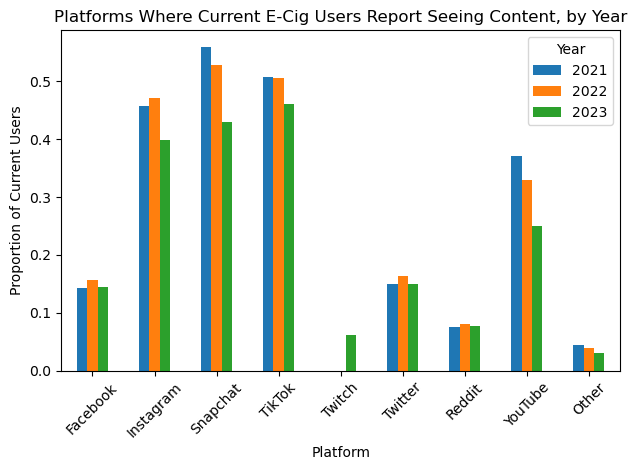

In [9]:
platform_by_year.T.plot(kind="bar")

plt.title("Platforms Where Current E-Cig Users Report Seeing Content, by Year")
plt.xlabel("Platform")
plt.ylabel("Proportion of Current Users")
plt.xticks(rotation=45)
plt.legend(title="Year")
plt.tight_layout()
plt.show()

In [10]:
# most popular platform each year among current users
top_platforms = platform_by_year.idxmax(axis=1)
top_platform_values = platform_by_year.max(axis=1)

top_platform_summary = pd.DataFrame({
    "top_platform": top_platforms,
    "share": top_platform_values
})

print(top_platform_summary)

     top_platform     share
year                       
2021     Snapchat  0.559889
2022     Snapchat  0.527953
2023       TikTok  0.460064


                     Non-Users  Current Users
People in Real Life   0.430729       0.405647
Online Friends        0.230032       0.198001
Influencers           0.364072       0.272536
Brands/Sellers        0.302207       0.220098
News                  0.099477       0.080673
Public Health         0.252396       0.147843
Other                 0.075516       0.064013


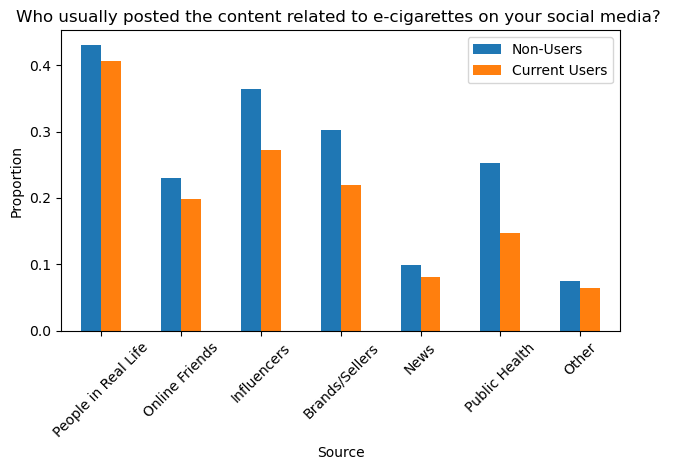

In [12]:
# plot content sources for users vs non-users
creator_cols = [
    "creator_real_life",
    "creator_online_friends",
    "creator_influencers",
    "creator_brands_sellers",
    "creator_news",
    "creator_public_health",
    "creator_other"
]

creator_labels = {
    "creator_real_life": "People in Real Life",
    "creator_online_friends": "Online Friends",
    "creator_influencers": "Influencers",
    "creator_brands_sellers": "Brands/Sellers",
    "creator_news": "News",
    "creator_public_health": "Public Health",
    "creator_other": "Other"
}

creator_compare = df.groupby("ecig_current")[creator_cols].mean().T
creator_compare = creator_compare.rename(index=creator_labels)
creator_compare.columns = ["Non-Users", "Current Users"]

print(creator_compare)

creator_compare.plot(kind="bar")

plt.title("Who usually posted the content related to e-cigarettes on your social media? ")
plt.xlabel("Source")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

                 age    sex  grade  sm_usage  sm_freq  post_freq  \
age            1.000 -0.055  0.880    -0.015   -0.058     -0.008   
sex           -0.055  1.000 -0.024     0.166    0.093      0.033   
grade          0.880 -0.024  1.000    -0.012   -0.038     -0.015   
sm_usage      -0.015  0.166 -0.012     1.000    0.090      0.061   
sm_freq       -0.058  0.093 -0.038     0.090    1.000      0.123   
post_freq     -0.008  0.033 -0.015     0.061    0.123      1.000   
interact_freq -0.083  0.094 -0.082     0.094    0.317      0.408   
ecig_current   0.018  0.030  0.030    -0.036    0.102      0.149   

               interact_freq  ecig_current  
age                   -0.083         0.018  
sex                    0.094         0.030  
grade                 -0.082         0.030  
sm_usage               0.094        -0.036  
sm_freq                0.317         0.102  
post_freq              0.408         0.149  
interact_freq          1.000         0.156  
ecig_current           0.15

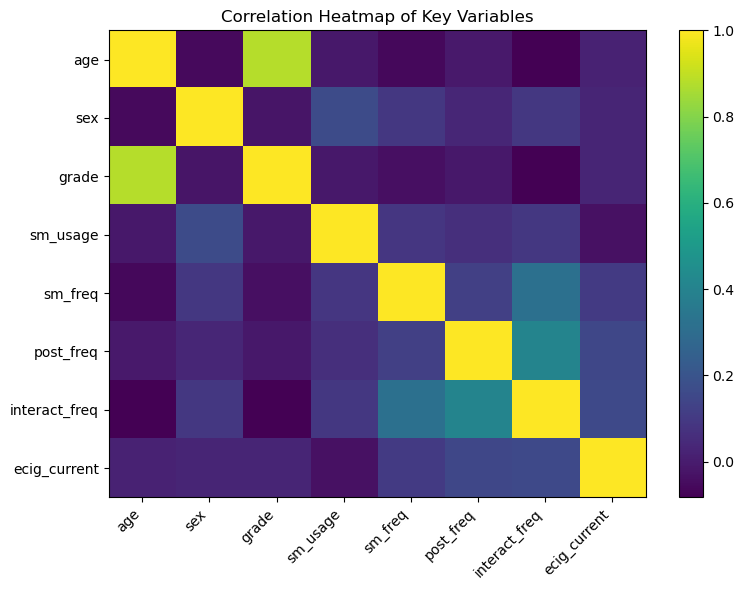

In [13]:
# make a correlation matrix for the numeric features
corr_cols = [
    "age", "sex", "grade",
    "sm_usage", "sm_freq", "post_freq", "interact_freq",
    "ecig_current"
]

corr_matrix = df[corr_cols].corr()
print(corr_matrix.round(3))

# plot a heatmap
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.imshow(corr_matrix, aspect="auto")

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticklabels(corr_cols)

plt.colorbar(cax)
plt.title("Correlation Heatmap of Key Variables")
plt.tight_layout()
plt.show()